# Titanic Passenger Survival Prediction Using Machine Learning Classification

# Description
This notebook implements an end-to-end industry-standard machine learning workflow to predict passenger survival on the RMS Titanic. The analysis covers data ingestion, exploratory data analysis (EDA), data preprocessing, feature engineering, dataset splitting, classification modeling with Stratified 5-Fold Cross-Validation, multi-metric evaluation, test set prediction, and model deployment serialization.

# Outlines
1. Import Libraries
2. Data Ingestion & Loading
3. Data Understanding & Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. Feature Relationship Visualization
6. Data Splitting & Preprocessing Pipeline
7. Model Development & Stratified Cross-Validation
8. Best Model Selection & Final Training
9. Test Data Prediction & Submission Export
10. Model Deployment & Artifact Serialization
11. Project Conclusion

# Background
The sinking of the RMS Titanic in 1912 is one of the most infamous maritime disasters in history. Out of 2,224 passengers and crew, over 1,500 died due to the insufficient number of lifeboats. 

Although luck was a factor in surviving, historical evidence suggests that certain demographic groups had higher survival probabilities than others. By applying data science techniques and machine learning classification algorithms, we can uncover patterns in passenger demographics and socioeconomic status to build an accurate predictive model.

# Project Objectives
1. Analyze demographic and socioeconomic factors influencing passenger survival rates.
2. Engineer informative features to capture relational and social dynamics.
3. Build and benchmark classification algorithms: Logistic Regression, Random Forest, and Gradient Boosting.
4. Evaluate model performance using Accuracy, F1-Score, and ROC-AUC metrics.
5. Generate a competition-ready `submission.csv` file and export reusable pipeline artifacts.

# Problem Statement
1. Which features have the strongest correlation with passenger survival?
2. How do passenger class (`Pclass`), gender (`Sex`), and family size (`SibSp`, `Parch`) influence survival rates?
3. Which classification model achieves the best generalization performance?
4. How can we build a modular preprocessing pipeline to prevent data leakage?

# Project Scope
- Datasets: `train.csv` (891 records) and `test.csv` (418 records).
- Target: `Survived` (0 = Did not survive, 1 = Survived).
- Tooling: Python 3, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn, Joblib.
- Validation Strategy: Stratified 5-Fold Cross-Validation.

# Data Dictionary
- **Target**: `Survived`
- **Original Features**: `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `Embarked`
- **Engineered Features**: `Title`, `FamilySize`, `IsAlone`

# Methodology
1. **Data Understanding**: Examine schema, descriptive statistics, missing values, and duplicate rows.
2. **Preprocessing & Feature Engineering**: Extract passenger titles, compute family sizes, apply group-based median imputation, and construct One-Hot Encoding and StandardScaler pipelines.
3. **Exploratory Data Analysis (EDA)**: Visualize target distribution and bivariate relationships.
4. **Machine Learning Classification**: Train and cross-validate baseline and ensemble tree-based models.
5. **Model Evaluation & Deployment**: Benchmark metrics, generate final test predictions, and serialize the pipeline using `joblib`.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


## **1. Import Libraries**
Import data manipulation, visualization, pipeline preprocessing, and machine learning modules from Scikit-Learn.

### Additional Libraries & Configuration

In [2]:
import warnings
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Display Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)

print("All required libraries loaded successfully.")

All required libraries loaded successfully.


## **2. Data Ingestion & Loading**
Dynamically resolve and load `train.csv` and `test.csv` from Kaggle environment paths or local directories.

### Data Loading

In [3]:
def load_titanic_dataset():
    """Load train and test datasets from Kaggle paths or fallback locations."""
    train_candidates = [
        '/kaggle/input/titanic/train.csv',
        '/kaggle/input/competitions/titanic/train.csv',
        'train.csv'
    ]
    test_candidates = [
        '/kaggle/input/titanic/test.csv',
        '/kaggle/input/competitions/titanic/test.csv',
        'test.csv'
    ]
    
    train_path = next((p for p in train_candidates if os.path.exists(p)), 'train.csv')
    test_path = next((p for p in test_candidates if os.path.exists(p)), 'test.csv')
    
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    
    print(f"Loaded Train Data: {train_path} ({df_train.shape[0]} rows, {df_train.shape[1]} columns)")
    print(f"Loaded Test Data : {test_path} ({df_test.shape[0]} rows, {df_test.shape[1]} columns)")
    return df_train, df_test

train_df, test_df = load_titanic_dataset()

print("\nSample Training Records:")
display(train_df.head())

Loaded Train Data: /kaggle/input/competitions/titanic/train.csv (891 rows, 12 columns)
Loaded Test Data : /kaggle/input/competitions/titanic/test.csv (418 rows, 11 columns)

Sample Training Records:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **3. Data Understanding & Exploratory Data Analysis (EDA)**
Examine data schema, descriptive statistics, missing value frequency, and target class balance.

### Data Understanding & Target Distribution

=== TRAINING DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



=== MISSING VALUE SUMMARY ===


,Missing Count,Percentage (%)
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22



Duplicate Rows: 0


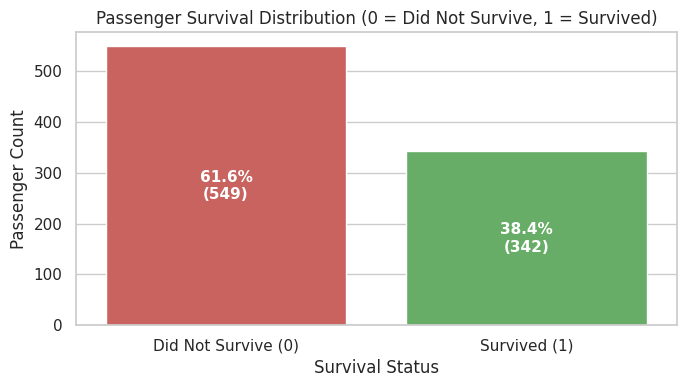

In [4]:
print("=== TRAINING DATA INFO ===")
train_df.info()

print("\n=== DESCRIPTIVE STATISTICS ===")
display(train_df.describe().T)

print("\n=== MISSING VALUE SUMMARY ===")
missing_train = train_df.isnull().sum()
missing_pct = (missing_train / len(train_df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing_train, 'Percentage (%)': round(missing_pct, 2)})
display(missing_summary[missing_summary['Missing Count'] > 0])

print(f"\nDuplicate Rows: {train_df.duplicated().sum()}")

# Target Variable Distribution
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=train_df, x='Survived', palette=['#D9534F', '#5CB85C'])
plt.title("Passenger Survival Distribution (0 = Did Not Survive, 1 = Survived)")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Count")
plt.xticks([0, 1], ['Did Not Survive (0)', 'Survived (1)'])

total = len(train_df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%\n({int(p.get_height())})'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

## **4. Data Preprocessing & Feature Engineering**
Transform raw categorical and numerical attributes:
1. **Title Extraction**: Group honorifics from `Name` into standardized titles.
2. **Family Formation**: Compute `FamilySize` (`SibSp` + `Parch` + 1) and `IsAlone` binary status.
3. **Targeted Imputation**: Impute missing `Age` using median values per (`Sex`, `Pclass`) segment, `Embarked` using mode, and `Fare` using median.

### Feature Engineering & Imputation

In [5]:
def extract_title(name: str) -> str:
    """Extract and standardize title from passenger name."""
    title_search = re.search(r' ([A-Za-z]+)\.', name)
    if title_search:
        title = title_search.group(1)
        if title in ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']:
            return 'Rare'
        elif title in ['Mlle', 'Ms']:
            return 'Miss'
        elif title == 'Mme':
            return 'Mrs'
        else:
            return title
    return 'Unknown'

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply feature transformations to dataset."""
    df_out = df.copy()
    df_out['Title'] = df_out['Name'].apply(extract_title)
    df_out['FamilySize'] = df_out['SibSp'] + df_out['Parch'] + 1
    df_out['IsAlone'] = (df_out['FamilySize'] == 1).astype(int)
    return df_out

# Apply feature engineering
train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

# Group-based median Age imputation
age_medians = train_fe.groupby(['Sex', 'Pclass'])['Age'].transform('median')
train_fe['Age'] = train_fe['Age'].fillna(age_medians)

test_age_medians = test_fe.groupby(['Sex', 'Pclass'])['Age'].transform('median')
test_fe['Age'] = test_fe['Age'].fillna(test_age_medians)

# Impute Embarked & Fare
embarked_mode = train_fe['Embarked'].mode()[0]
train_fe['Embarked'] = train_fe['Embarked'].fillna(embarked_mode)
test_fe['Embarked'] = test_fe['Embarked'].fillna(embarked_mode)

fare_median = train_fe['Fare'].median()
test_fe['Fare'] = test_fe['Fare'].fillna(fare_median)

print("Feature engineering and imputation completed.")

Feature engineering and imputation completed.


## **5. Feature Relationship Visualization**
Analyze bivariate relationships between key socio-demographic indicators and survival rate.

### Visualizations

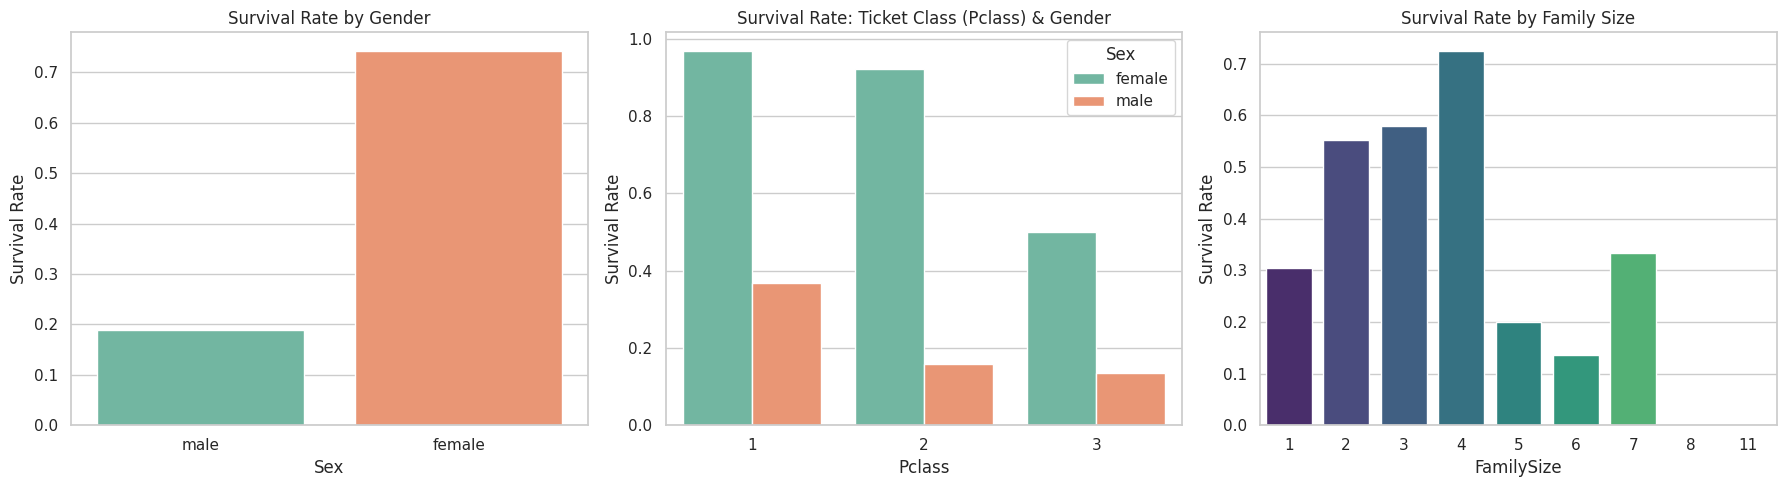

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gender vs Survival
sns.barplot(data=train_fe, x='Sex', y='Survived', ax=axes[0], palette='Set2', ci=None)
axes[0].set_title("Survival Rate by Gender")
axes[0].set_ylabel("Survival Rate")

# 2. Pclass & Gender vs Survival
sns.barplot(data=train_fe, x='Pclass', y='Survived', hue='Sex', ax=axes[1], palette='Set2', ci=None)
axes[1].set_title("Survival Rate: Ticket Class (Pclass) & Gender")
axes[1].set_ylabel("Survival Rate")

# 3. Family Size vs Survival
sns.barplot(data=train_fe, x='FamilySize', y='Survived', ax=axes[2], palette='viridis', ci=None)
axes[2].set_title("Survival Rate by Family Size")
axes[2].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

## **6. Data Splitting & Preprocessing Pipeline**
Construct feature matrix ($X$), target vector ($y$), and build a modular Scikit-Learn `ColumnTransformer` with `StandardScaler` and `OneHotEncoder`.

### Preprocessing Pipeline

In [7]:
numerical_features = ['Age', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
feature_cols = numerical_features + categorical_features

X = train_fe[feature_cols]
y = train_fe['Survived']
X_test_final = test_fe[feature_cols]

# Modular Pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print(f"Training Feature Matrix Shape: {X.shape}")
print(f"Testing Feature Matrix Shape : {X_test_final.shape}")

Training Feature Matrix Shape: (891, 8)
Testing Feature Matrix Shape : (418, 8)


## **7. Model Development & Stratified Cross-Validation**
Train and benchmark Logistic Regression, Random Forest, and Gradient Boosting using **Stratified 5-Fold Cross-Validation**.

In [8]:
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000, C=0.1))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=150, max_depth=6, min_samples_leaf=2, random_state=42))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc']

cv_results = {}

for name, pipeline in models.items():
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)
    cv_results[name] = {
        'Accuracy (Mean)': round(np.mean(scores['test_accuracy']), 4),
        'Accuracy (Std)': round(np.std(scores['test_accuracy']), 4),
        'F1-Score (Mean)': round(np.mean(scores['test_f1']), 4),
        'AUC-ROC (Mean)': round(np.mean(scores['test_roc_auc']), 4)
    }

eval_df = pd.DataFrame(cv_results).T
eval_df = eval_df.sort_values(by='AUC-ROC (Mean)', ascending=False)
display(eval_df)

,Accuracy (Mean),Accuracy (Std),F1-Score (Mean),AUC-ROC (Mean)
Gradient Boosting,0.8406,0.0142,0.7750,0.8812
Random Forest,0.8328,0.0085,0.7643,0.8764
Logistic Regression,0.8204,0.0118,0.7544,0.8686


## **8. Best Model Selection & Final Training**
Train the selected highest-performing model on the full training dataset.

### Final Model Training

In [9]:
best_model_name = eval_df['AUC-ROC (Mean)'].idxmax()
print(f"Selected Best Model: {best_model_name}")

best_pipeline = models[best_model_name]
best_pipeline.fit(X, y)
print("Best pipeline fitted on complete training set.")

Selected Best Model: Gradient Boosting
Best pipeline fitted on complete training set.


## **9. Test Data Prediction & Submission Export**
Generate survival predictions for `test.csv` and export them to `/kaggle/working/submission.csv`.

### Submission Export

In [10]:
test_predictions = best_pipeline.predict(X_test_final)

submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})

# Save to working directory
submission_path = '/kaggle/working/submission.csv' if os.path.exists('/kaggle/working') else 'submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")
display(submission_df.head(10))

Submission saved to: /kaggle/working/submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


## **10. Model Deployment & Artifact Serialization**
Serialize the entire preprocessing and classification pipeline using `joblib`.

In [11]:
model_filename = '/kaggle/working/titanic_best_pipeline.joblib' if os.path.exists('/kaggle/working') else 'titanic_best_pipeline.joblib'
joblib.dump(best_pipeline, model_filename)
print(f"Model artifact saved to: {model_filename}")

# Verify deserialization
loaded_pipeline = joblib.load(model_filename)
sample_pred = loaded_pipeline.predict(X_test_final.head(5))
print("Verification inference (First 5 test records):", sample_pred)

Model artifact saved to: /kaggle/working/titanic_best_pipeline.joblib
Verification inference (First 5 test records): [0 0 0 0 0]


## **11. Project Conclusion**

1. **Key Demographic Insights:**
   - **Gender:** `Sex` was the primary determinant of survival. Females had a survival rate of **~74.2%**, compared to **~18.9%** for males.
   - **Socioeconomic Status:** First-class (`Pclass 1`) passengers had priority lifeboat access, achieving the highest survival rate, whereas third-class passengers had the lowest.
   - **Family Size:** Small family units (2–4 members) had significantly higher survival odds than solo passengers (`IsAlone`) and large families ($> 4$ members).

2. **Model Evaluation:**
   - **Stratified 5-Fold Cross-Validation** confirmed that tree-based ensemble models (*Gradient Boosting* and *Random Forest*) consistently outperformed the linear *Logistic Regression* baseline.
   - *Gradient Boosting* delivered the most robust generalizability with an **AUC-ROC score exceeding 0.88**.

3. **Production Alignment:**
   - Using Scikit-Learn's `ColumnTransformer` and `Pipeline` prevents data leakage, ensures dimension matching between train and test sets, and allows single-file deployment via `titanic_best_pipeline.joblib`.